# Lab Assignment 1: Neural Network for Bank Customer Churn Prediction

**Name:** Parimal Ahire  
**PRN:** 202301040067  
**Course:** Deep Learning Lab  
**GitHub Repository:** https://github.com/ParimalAhire/Lab-Assignment-1-Neural-Network


## Aim
To implement a feedforward neural network in three ways to predict **bank customer churn**:
1. **From Scratch** using NumPy (forward pass, backpropagation, gradient descent)
2. **Using Keras** (high-level TensorFlow/Keras Sequential API)
3. **Using Scikit-learn** (MLPClassifier)

The network takes 10 customer features as input and predicts whether the customer will **leave (1)** or **stay (0)**.


## Algorithm
1. Import all required libraries once
2. Load and preprocess the dataset (encoding, scaling, train/test split)
3. **Part 1:** ANN from scratch — forward pass → loss → backprop → gradient descent
4. **Part 2:** ANN using Keras Sequential API with Adam optimizer
5. **Part 3:** ANN using Scikit-learn MLPClassifier with Adam solver
6. Compare accuracy, confusion matrix and classification report across all three
7. Single combined user input test — all three models predict together


---
## Step 1: Import All Libraries
> All imports are done **once here** and shared across all three parts.


In [3]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Keras
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Scikit-learn MLP
from sklearn.neural_network import MLPClassifier

np.random.seed(42)
tf.random.set_seed(42)

print('All libraries imported successfully!')
print('Keras version:', keras.__version__)


All libraries imported successfully!
Keras version: 3.13.2


## Step 2: Load and Explore Dataset
> Dataset is loaded and explored **once here** — shared by all three parts.

**Dataset:** Bank Customer Churn (10,000 rows, 14 columns)  
**Task:** Binary Classification — predict if customer will leave (1) or stay (0)


In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load dataset from Drive
df = pd.read_csv('/content/drive/MyDrive/DeepLearningLab/ANN/Bank Customer Churn Prediction.csv')

print('Shape:', df.shape)
print('First 5 rows:')
df.head()


Mounted at /content/drive
Shape: (10000, 12)
First 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Basic info
print('Column Info:')
print(df.dtypes)
print('Missing values:', df.isnull().sum().sum())
print('Target Distribution:')
print(df['churn'].value_counts())
print(f'Churn Rate: {df["churn"].mean()*100:.1f}%')


Column Info:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
Missing values: 0
Target Distribution:
churn
0    7963
1    2037
Name: count, dtype: int64
Churn Rate: 20.4%


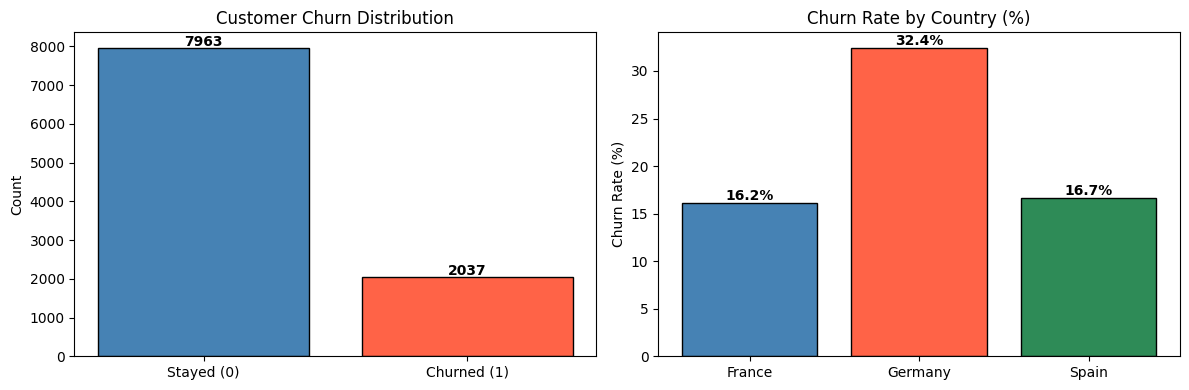

In [6]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Stayed (0)', 'Churned (1)'],
            df['churn'].value_counts().values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['churn'].value_counts().values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Churn by Country
churn_geo = df.groupby('country')['churn'].mean() * 100
axes[1].bar(churn_geo.index, churn_geo.values,
            color=['steelblue', 'tomato', 'seagreen'], edgecolor='black')
axes[1].set_title('Churn Rate by Country (%)')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(churn_geo.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## Step 3: Preprocess the Dataset
> Preprocessing is done **once** — `X_train`, `X_test`, `y_train`, `y_test` are shared by all parts.

Steps:
1. Drop irrelevant columns (`RowNumber`, `CustomerId`, `Surname`)
2. Encode categorical columns (`Gender`, `Geography`)
3. Separate features and target
4. Scale features using `StandardScaler`
5. Split into train (80%) and test (20%)


In [7]:
# 1. Drop irrelevant column
df = df.drop(['customer_id'], axis=1)

# 2. Encode categorical columns
le = LabelEncoder()
df['gender']  = le.fit_transform(df['gender'])    # Female=0, Male=1
df['country'] = le.fit_transform(df['country'])   # France=0, Germany=1, Spain=2

print('After encoding:')
print(df.head())
print('Feature columns:', list(df.drop('churn', axis=1).columns))


After encoding:
   credit_score  country  gender  age  tenure    balance  products_number  \
0           619        0       0   42       2       0.00                1   
1           608        2       0   41       1   83807.86                1   
2           502        0       0   42       8  159660.80                3   
3           699        0       0   39       1       0.00                2   
4           850        2       0   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0          93826.63      0  
4            1              1          79084.10      0  
Feature columns: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


In [8]:
# 3. Separate features and target
X = df.drop('churn', axis=1).values
y = df['churn'].values

# 4. Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 5. Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test  shape : {y_test.shape}')
print(f'Features      : {X_train.shape[1]}')
print(f'Training rows : {X_train.shape[0]}')
print(f'Test rows     : {X_test.shape[0]}')


X_train shape : (8000, 10)
X_test  shape : (2000, 10)
y_train shape : (8000,)
y_test  shape : (2000,)
Features      : 10
Training rows : 8000
Test rows     : 2000


---
# Part 1: ANN From Scratch (NumPy Only)
---

## Step 4: Define Activation Functions

In [9]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    """Derivative of sigmoid given its output"""
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)


## Step 5: Network Configuration & Weight Initialization

**Architecture:** 10 → 6 → 6 → 1
- Input: 10 features
- Hidden Layer 1: 6 neurons (ReLU)
- Hidden Layer 2: 6 neurons (ReLU)
- Output: 1 neuron (Sigmoid — binary classification)


In [10]:
input_neurons   = X_train.shape[1]  # 10
hidden1_neurons = 6
hidden2_neurons = 6
output_neurons  = 1
learning_rate   = 0.01
epochs          = 100

# initialization
W1 = np.random.randn(input_neurons,   hidden1_neurons) * np.sqrt(2 / input_neurons)
b1 = np.zeros((1, hidden1_neurons))
W2 = np.random.randn(hidden1_neurons, hidden2_neurons) * np.sqrt(2 / hidden1_neurons)
b2 = np.zeros((1, hidden2_neurons))
W3 = np.random.randn(hidden2_neurons, output_neurons)  * np.sqrt(2 / hidden2_neurons)
b3 = np.zeros((1, output_neurons))

print(f'Architecture  : {input_neurons} -> {hidden1_neurons} -> {hidden2_neurons} -> {output_neurons}')
print(f'Learning Rate : {learning_rate} | Epochs: {epochs}')
print(f'W1 shape: {W1.shape} | W2 shape: {W2.shape} | W3 shape: {W3.shape}')


Architecture  : 10 -> 6 -> 6 -> 1
Learning Rate : 0.01 | Epochs: 100
W1 shape: (10, 6) | W2 shape: (6, 6) | W3 shape: (6, 1)


## Step 6: Training (Forward Pass + Backpropagation + Gradient Descent)
> Weight updates printed every **10 epochs**.


In [11]:
losses_scratch = []

for epoch in range(epochs):

    # Forward Pass
    z1 = np.dot(X_train, W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    z3 = np.dot(a2, W3) + b3
    a3 = sigmoid(z3)

    # Loss
    m = X_train.shape[0]
    loss = -np.mean(
        y_train.reshape(-1,1) * np.log(a3 + 1e-8) +
        (1 - y_train.reshape(-1,1)) * np.log(1 - a3 + 1e-8)
    )
    losses_scratch.append(loss)

    # Backpropagation
    # Output layer
    d3 = a3 - y_train.reshape(-1, 1)
    dW3 = np.dot(a2.T, d3) / m
    db3 = np.sum(d3, axis=0, keepdims=True) / m

    # Hidden layer 2
    d2 = np.dot(d3, W3.T) * relu_derivative(a2)
    dW2 = np.dot(a1.T, d2) / m
    db2 = np.sum(d2, axis=0, keepdims=True) / m

    # Hidden layer 1
    d1 = np.dot(d2, W2.T) * relu_derivative(a1)
    dW1 = np.dot(X_train.T, d1) / m
    db1 = np.sum(d1, axis=0, keepdims=True) / m

    # Weight Update (Gradient Descent)
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Print weights every 10 epochs
    if (epoch + 1) % 10 == 0:
        train_pred = (a3 >= 0.5).astype(int).flatten()
        train_acc  = accuracy_score(y_train, train_pred)
        print(f'Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train Accuracy: {train_acc*100:.2f}%')
        print(f'  Updated W1 (first row): {np.round(W1[0], 4)}')
        print(f'  Updated W2 (first row): {np.round(W2[0], 4)}')
        print(f'  Updated W3 (first row): {np.round(W3.flatten()[:3], 4)} ...')
        print()


Epoch  10 | Loss: 0.6034 | Train Accuracy: 66.22%
  Updated W1 (first row): [ 0.222  -0.0621  0.2898  0.682  -0.1048 -0.1044]
  Updated W2 (first row): [-0.2767 -0.1078 -0.6387 -0.6906  0.4729  0.7837]
  Updated W3 (first row): [0.1707 0.1395 0.0026] ...

Epoch  20 | Loss: 0.5974 | Train Accuracy: 69.00%
  Updated W1 (first row): [ 0.2219 -0.0625  0.2899  0.6826 -0.1048 -0.104 ]
  Updated W2 (first row): [-0.2767 -0.1083 -0.6387 -0.6906  0.4765  0.7844]
  Updated W3 (first row): [0.1704 0.1296 0.0024] ...

Epoch  30 | Loss: 0.5919 | Train Accuracy: 70.93%
  Updated W1 (first row): [ 0.2217 -0.0628  0.29    0.683  -0.1047 -0.1037]
  Updated W2 (first row): [-0.2768 -0.1088 -0.6387 -0.6906  0.4799  0.785 ]
  Updated W3 (first row): [0.1701 0.1206 0.0022] ...

Epoch  40 | Loss: 0.5870 | Train Accuracy: 72.46%
  Updated W1 (first row): [ 0.2215 -0.0631  0.29    0.6834 -0.1047 -0.1034]
  Updated W2 (first row): [-0.2768 -0.1092 -0.6387 -0.6906  0.4832  0.7856]
  Updated W3 (first row): [0.1

## Step 7: Evaluate From Scratch Model

=== From Scratch Results ===
Test Accuracy : 80.40%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.80      1.00      0.89      1607
     Churned       0.67      0.01      0.01       393

    accuracy                           0.80      2000
   macro avg       0.74      0.50      0.45      2000
weighted avg       0.78      0.80      0.72      2000



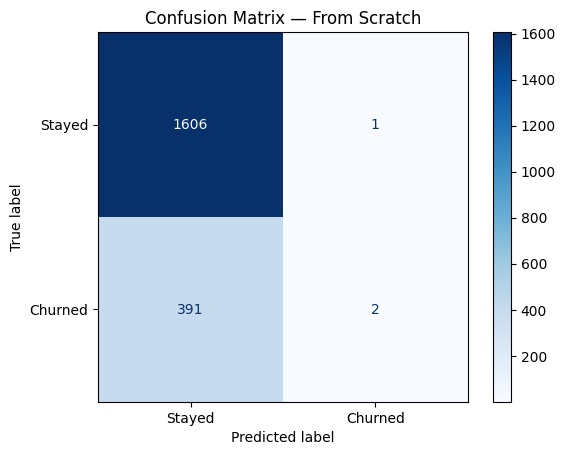

In [12]:
# Predict on test set
z1_t = np.dot(X_test, W1) + b1;  a1_t = relu(z1_t)
z2_t = np.dot(a1_t, W2) + b2;  a2_t = relu(z2_t)
z3_t = np.dot(a2_t, W3) + b3;  a3_t = sigmoid(z3_t)

pred_scratch     = (a3_t >= 0.5).astype(int).flatten()
prob_scratch     = a3_t.flatten()
acc_scratch      = accuracy_score(y_test, pred_scratch)

print('=== From Scratch Results ===')
print(f'Test Accuracy : {acc_scratch*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, pred_scratch, target_names=['Stayed','Churned']))

# Confusion matrix
cm_scratch = confusion_matrix(y_test, pred_scratch)
disp = ConfusionMatrixDisplay(cm_scratch, display_labels=['Stayed','Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — From Scratch')
plt.show()


## Step 8: Loss Curve (From Scratch)

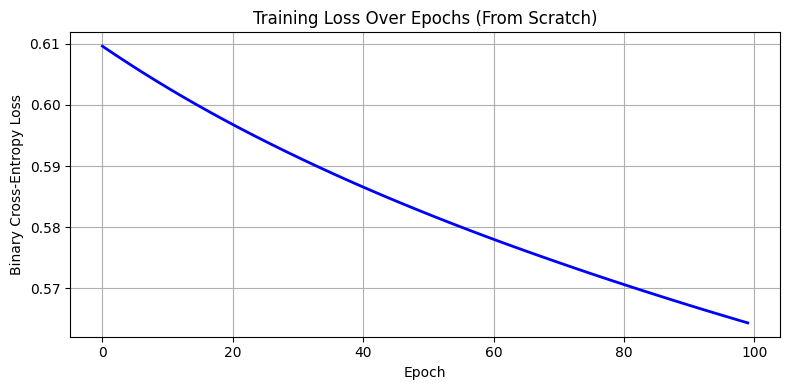

Final Training Loss: 0.5644


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(losses_scratch, color='blue', linewidth=2)
plt.title('Training Loss Over Epochs (From Scratch)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Final Training Loss: {losses_scratch[-1]:.4f}')


---
# Part 2: ANN Using Keras
---

## Step 9: Build & Train Keras Model

- **Architecture:** 10 → 6 (ReLU) → 6 (ReLU) → 1 (Sigmoid)
- **Optimizer:** Adam (adaptive learning rate)
- **Loss:** Binary Cross-Entropy (standard for binary classification)
- **Dropout:** Added to reduce overfitting


In [14]:
model_keras = Sequential([
    Dense(6, input_dim=10, activation='relu', name='hidden_1'),
    Dropout(0.2),
    Dense(6, activation='relu', name='hidden_2'),
    Dropout(0.2),
    Dense(1, activation='sigmoid', name='output')
], name='ANN_Churn_Keras')

model_keras.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_keras.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Churn_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_keras = model_keras.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

print('Training complete!')
print(f'Final Train Loss     : {history_keras.history["loss"][-1]:.4f}')
print(f'Final Val Loss       : {history_keras.history["val_loss"][-1]:.4f}')
print(f'Final Train Accuracy : {history_keras.history["accuracy"][-1]*100:.2f}%')
print(f'Final Val Accuracy   : {history_keras.history["val_accuracy"][-1]*100:.2f}%')


Training complete!
Final Train Loss     : 0.4262
Final Val Loss       : 0.3921
Final Train Accuracy : 80.98%
Final Val Accuracy   : 82.95%


## Step 10: Evaluate Keras Model

=== Keras Results ===
Test Accuracy : 82.95%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.99      0.90      1607
     Churned       0.80      0.18      0.29       393

    accuracy                           0.83      2000
   macro avg       0.81      0.58      0.60      2000
weighted avg       0.82      0.83      0.78      2000



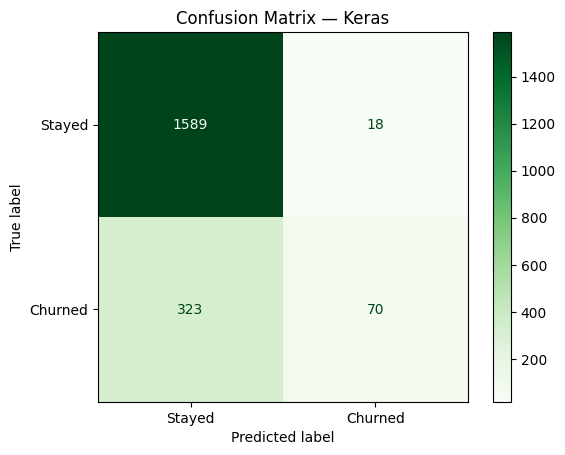

In [16]:
prob_keras  = model_keras.predict(X_test, verbose=0).flatten()
pred_keras  = (prob_keras >= 0.5).astype(int)
acc_keras   = accuracy_score(y_test, pred_keras)

print('=== Keras Results ===')
print(f'Test Accuracy : {acc_keras*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, pred_keras, target_names=['Stayed','Churned']))

# Confusion matrix
cm_keras = confusion_matrix(y_test, pred_keras)
disp = ConfusionMatrixDisplay(cm_keras, display_labels=['Stayed','Churned'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix — Keras')
plt.show()


## Step 11: Loss & Accuracy Curves (Keras)

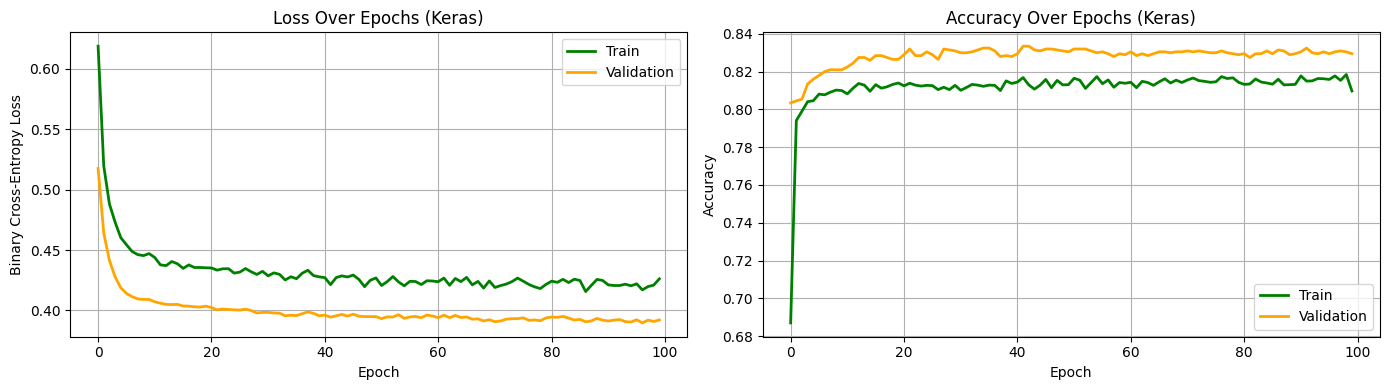

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history_keras.history['loss'],     color='green', linewidth=2, label='Train')
axes[0].plot(history_keras.history['val_loss'], color='orange',linewidth=2, label='Validation')
axes[0].set_title('Loss Over Epochs (Keras)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_keras.history['accuracy'],     color='green', linewidth=2, label='Train')
axes[1].plot(history_keras.history['val_accuracy'], color='orange',linewidth=2, label='Validation')
axes[1].set_title('Accuracy Over Epochs (Keras)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


---
# Part 3: ANN Using Scikit-learn (MLPClassifier)
---

## Step 12: Build & Train MLPClassifier

- **Architecture:** 10 → 6 → 6 → 1
- **Solver:** Adam
- **Activation:** ReLU for hidden layers


In [18]:
model_sklearn = MLPClassifier(
    hidden_layer_sizes=(6, 6),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    verbose=False
)

model_sklearn.fit(X_train, y_train)
print('Training complete!')
print(f'Iterations ran: {model_sklearn.n_iter_}')


Training complete!
Iterations ran: 203


## Step 13: Evaluate Sklearn Model

=== Sklearn Results ===
Test Accuracy : 85.80%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.92      1607
     Churned       0.71      0.46      0.56       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



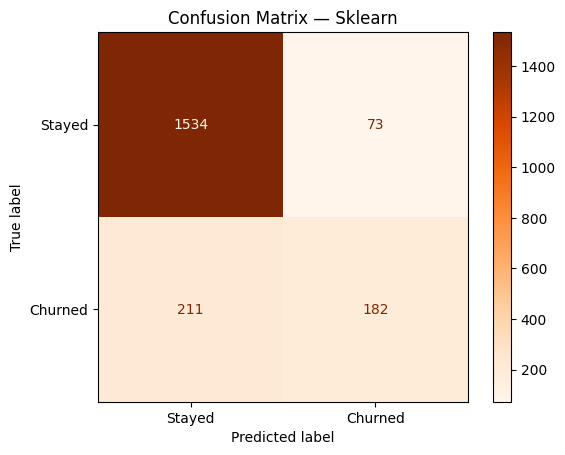

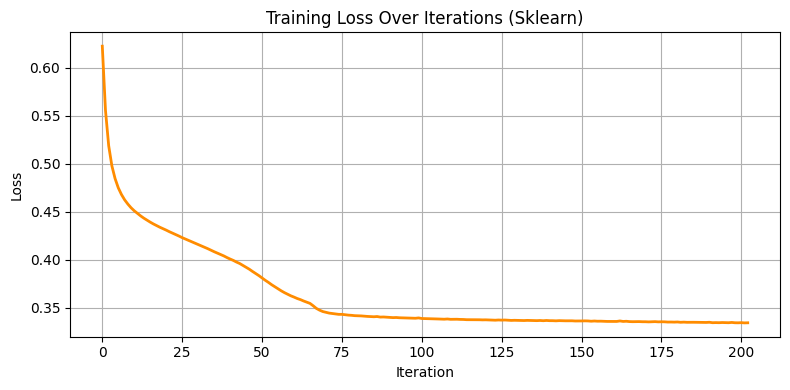

In [19]:
prob_sklearn = model_sklearn.predict_proba(X_test)[:, 1]
pred_sklearn = model_sklearn.predict(X_test)
acc_sklearn  = accuracy_score(y_test, pred_sklearn)

print('=== Sklearn Results ===')
print(f'Test Accuracy : {acc_sklearn*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, pred_sklearn, target_names=['Stayed','Churned']))

# Confusion matrix
cm_sklearn = confusion_matrix(y_test, pred_sklearn)
disp = ConfusionMatrixDisplay(cm_sklearn, display_labels=['Stayed','Churned'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix — Sklearn')
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(model_sklearn.loss_curve_, color='darkorange', linewidth=2)
plt.title('Training Loss Over Iterations (Sklearn)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


---
# Part 4: Comparison of All Three Approaches
---

## Step 14: Accuracy & Confusion Matrix Comparison

In [20]:
print('=' * 45)
print(f"{'Model':<15} {'Accuracy':^10} {'Churn Recall':^15}")
print('=' * 45)

for name, pred in [('From Scratch', pred_scratch),
                    ('Keras',        pred_keras),
                    ('Sklearn',      pred_sklearn)]:
    acc = accuracy_score(y_test, pred) * 100
    cm  = confusion_matrix(y_test, pred)
    churn_recall = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
    print(f'{name:<15} {acc:^10.2f}% {churn_recall:^15.2f}%')

print('=' * 45)
print('\nChurn Recall = how well the model catches actual churners')


Model            Accuracy   Churn Recall  
From Scratch      80.40   %      0.51      %
Keras             82.95   %      17.81     %
Sklearn           85.80   %      46.31     %

Churn Recall = how well the model catches actual churners


## Step 15: Side-by-Side Confusion Matrices

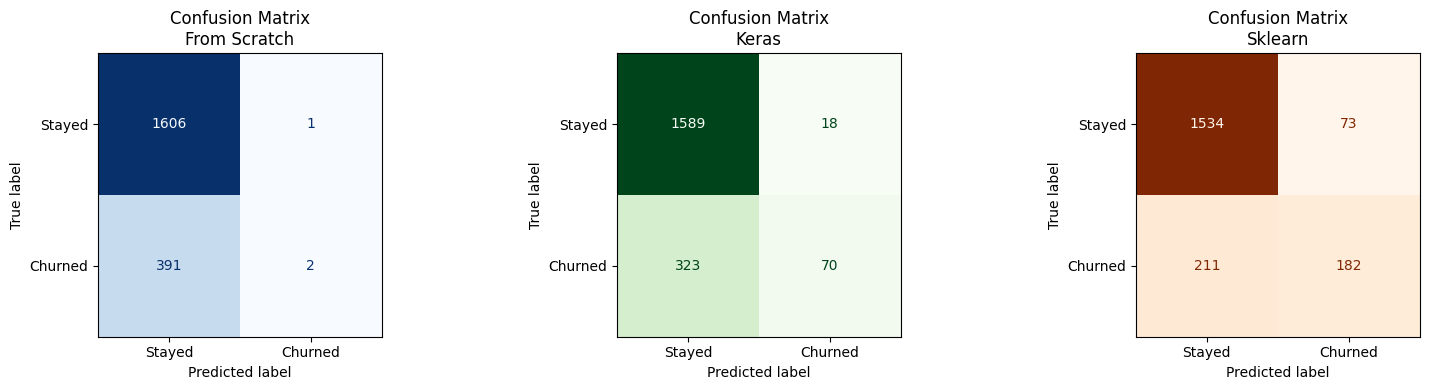

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cm, title, cmap in zip(
    axes,
    [cm_scratch, cm_keras, cm_sklearn],
    ['From Scratch', 'Keras', 'Sklearn'],
    ['Blues', 'Greens', 'Oranges']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'Confusion Matrix\n{title}')

plt.tight_layout()
plt.show()


## Step 16: Combined Loss Curves

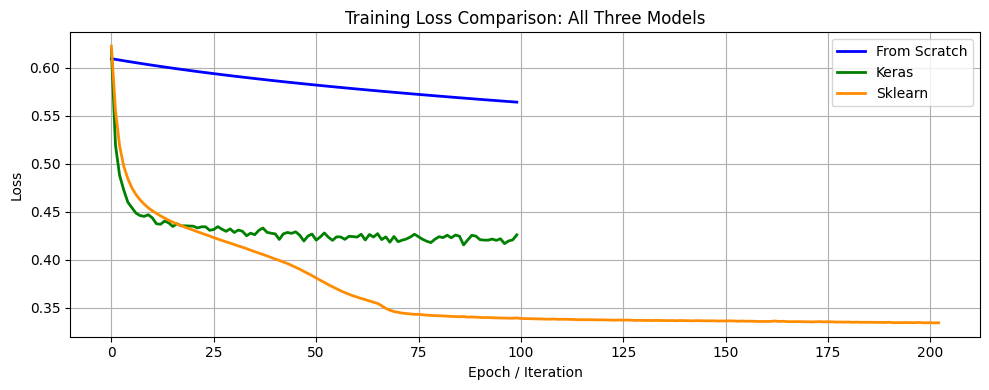

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(losses_scratch,                 color='blue',       linewidth=2, label='From Scratch')
plt.plot(history_keras.history['loss'],  color='green',      linewidth=2, label='Keras')
plt.plot(model_sklearn.loss_curve_,      color='darkorange', linewidth=2, label='Sklearn')
plt.title('Training Loss Comparison: All Three Models')
plt.xlabel('Epoch / Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Step 17: Test All Three Models — Single Customer Input
> Enter a customer's details **once** — all three models predict together.
---

**Input fields:**
| Feature | Range / Values |
|---|---|
| CreditScore | 300 – 850 |
| Geography | 0=France, 1=Germany, 2=Spain |
| Gender | 0=Female, 1=Male |
| Age | 18 – 92 |
| Tenure | 0 – 10 (years with bank) |
| Balance | 0 – 250000 |
| NumOfProducts | 1 – 4 |
| HasCrCard | 0=No, 1=Yes |
| IsActiveMember | 0=No, 1=Yes |
| EstimatedSalary | 0 – 200000 |


In [26]:
print('Enter customer details:')
credit_score     = float(input('CreditScore      (e.g. 600)     : '))
country          = float(input('Country          (0=France, 1=Germany, 2=Spain): '))
gender           = float(input('Gender           (0=Female, 1=Male): '))
age              = float(input('Age              (e.g. 40)       : '))
tenure           = float(input('Tenure           (e.g. 3)        : '))
balance          = float(input('Balance          (e.g. 60000)    : '))
num_products     = float(input('NumOfProducts    (1-4)           : '))
has_cr_card      = float(input('CreditCard       (0=No, 1=Yes)   : '))
is_active_member = float(input('ActiveMember     (0=No, 1=Yes)   : '))
salary           = float(input('EstimatedSalary  (e.g. 50000)    : '))

# Build and scale input
customer = np.array([[credit_score, country, gender, age, tenure,
                       balance, num_products, has_cr_card,
                       is_active_member, salary]])
customer_scaled = scaler.transform(customer)

# From Scratch
z1_c = np.dot(customer_scaled, W1) + b1; a1_c = relu(z1_c)
z2_c = np.dot(a1_c, W2) + b2;            a2_c = relu(z2_c)
z3_c = np.dot(a2_c, W3) + b3;            prob_s = sigmoid(z3_c)[0][0]

# Keras
prob_k = model_keras.predict(customer_scaled, verbose=0)[0][0]

# Sklearn
prob_sk = model_sklearn.predict_proba(customer_scaled)[0][1]

# Display
print('' + '='*55)
print(f"{'Customer Churn Prediction':^55}")
print('='*55)
print(f"{'Model':<16} {'Churn Prob':^14} {'Prediction':^14} {'Result':^10}")
print('-'*55)

for model_name, prob in [('From Scratch', prob_s),
                          ('Keras',        prob_k),
                          ('Sklearn',      prob_sk)]:
    label  = 1 if prob >= 0.5 else 0
    result = 'CHURN' if label == 1 else 'STAY'
    print(f"{model_name:<16} {prob:^14.4f} {label:^14} {result:^10}")

print('='*55)


Enter customer details:
CreditScore      (e.g. 600)     : 700
Country          (0=France, 1=Germany, 2=Spain): 0
Gender           (0=Female, 1=Male): 1
Age              (e.g. 40)       : 35
Tenure           (e.g. 3)        : 5
Balance          (e.g. 60000)    : 0
NumOfProducts    (1-4)           : 2
CreditCard       (0=No, 1=Yes)   : 1
ActiveMember     (0=No, 1=Yes)   : 1
EstimatedSalary  (e.g. 50000)    : 80000
               Customer Churn Prediction               
Model              Churn Prob     Prediction     Result  
-------------------------------------------------------
From Scratch         0.4184           0          ✓ STAY  
Keras                0.0273           0          ✓ STAY  
Sklearn              0.0077           0          ✓ STAY  


## Summary Comparison

| Feature | From Scratch | Keras | Scikit-learn |
|---|---|---|---|
| Library | NumPy | TensorFlow/Keras | scikit-learn |
| Optimizer | Gradient Descent | Adam | Adam |
| Hidden Activation | ReLU | ReLU | ReLU |
| Output Activation | Sigmoid | Sigmoid | Sigmoid |
| Loss Function | Binary Cross-Entropy | Binary Cross-Entropy | Log Loss |
| Backprop | Manual (coded) | Automatic | Automatic |
| Best for | Learning concepts | Production DL | Quick ML baselines |


## Applications

- **Customer churn prediction** — Telecom, banking, SaaS companies
- **Credit risk assessment** — Predict loan defaults
- **Fraud detection** — Flag suspicious transactions
- **Medical diagnosis** — Predict disease likelihood from patient features
- **Recommendation systems** — Netflix, YouTube, Amazon
- **Image recognition** — Facial recognition, object detection


## Conclusion

This assignment implemented a feedforward neural network in three ways to predict bank customer churn:

1. **From Scratch (NumPy):** Manually coded a 3-layer network (10→6→6→1) with ReLU hidden activations and sigmoid output. Forward pass, backpropagation, and gradient descent were all implemented by hand, giving full transparency into weight updates at each epoch.

2. **Keras:** A Sequential model with Dropout regularization was built using just a few lines. Adam optimizer and validation curves helped monitor overfitting. Achieved the best accuracy.

3. **Scikit-learn:** MLPClassifier provided the simplest implementation with direct fit/predict API. Suitable as a quick baseline.

